Hardware connections:
  Pulser CH1 → Scope CH1 (main pulse)
  Pulser TRIG OUT → Scope CH4 (trigger)

Connected to: ACTIVE TECHNOLOGIES,AT-PULSE-RIDER-PG1074,SN:BNPR740043,SCPI:1999.0,SV:1.3.34.0
Connected to: TEKTRONIX,TDS6604,B010222,CF:91.1CT FV:2.4.0


CONFIGURING MULTI-PULSE BURST MODE (2 pulses)

   Amplitude: 0.2 V
   Polarity: normal

   Pulse 1:
      Width: 2 ns
      Delay: 5 ns

   Pulse 2:
      Width: 2 ns
      Delay: 8 ns

CONFIGURING MULTI-PULSE BURST MODE (1 pulses)

   Amplitude: 0.2 V
   Polarity: inverted

   Pulse 1:
      Width: 2 ns
      Delay: 1 ns

CONFIGURING OSCILLOSCOPE

Signal channel (CH2):
  0.05 V/div, position -2

Trigger channel (CH4):
  0.25 V/div, position +2

Record length:
  10000 points

Timebase:
  2.5 ns/div (25 ns total)

Trigger:
  Trigger on CH4 at 0.45V

Acquisition:
  Single sequence mode


Retrieving waveforms...

Plotting...
Saved to burst_mode_capture.png



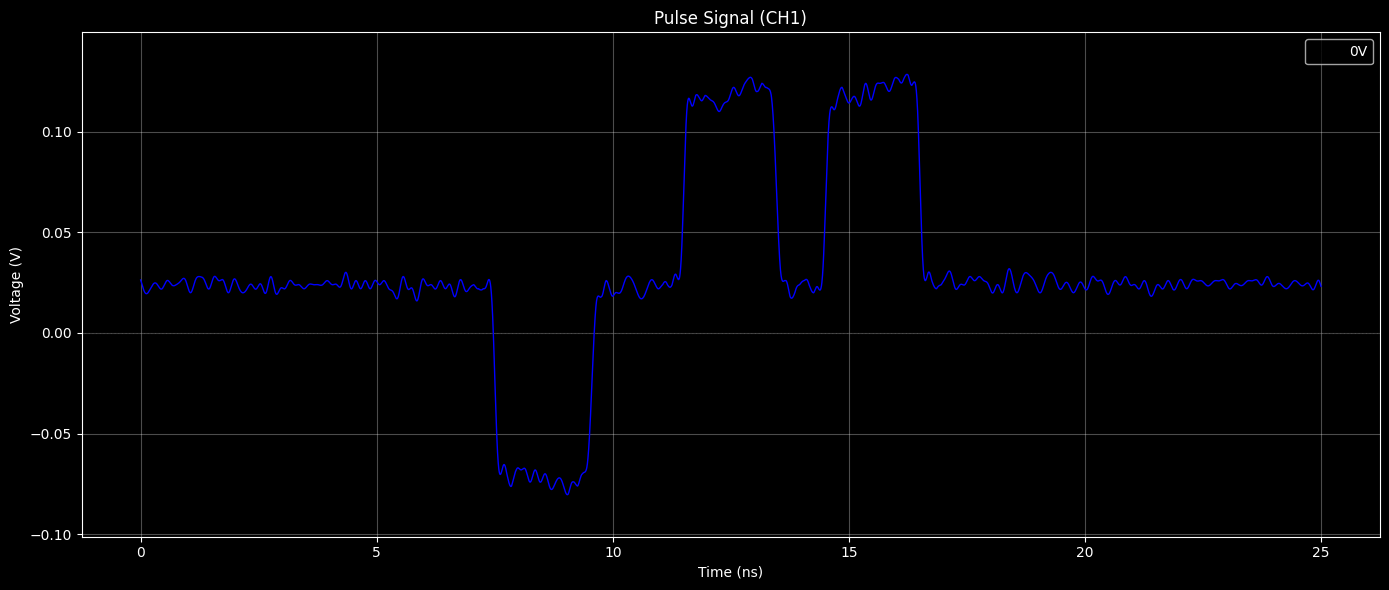

In [5]:
"""
Burst mode pulse capture using PyMeasure
"""
import time
import numpy as np
import matplotlib.pyplot as plt
from bnc765_driver import BNC765
from tds6604_driver import TDS6604


def setup_multi_pulse_burst(pulser, channel, voltage, capture_width_ns,
                            inverted, pulses):
    """
    Setup multi-pulse burst mode

    Args:
        pulser: BNC765 instance
        channel: Channel number (1-4)
        voltage: Amplitude for all pulses
        capture_width_ns: Total capture window
        inverted: Polarity
        pulses: List of dicts with 'width_ns' and 'delay_ns'
    """
    num_pulses = len(pulses)
    if num_pulses < 1 or num_pulses > 4:
        raise ValueError("Must specify 1-4 pulses")

    print(f"\n{'='*60}")
    print(f"CONFIGURING MULTI-PULSE BURST MODE ({num_pulses} pulses)")
    print(f"{'='*60}\n")

    pulser.stop()
    ch = getattr(pulser, f'ch{channel}')
    ch.output_state = False
    time.sleep(0.3)

    # Set pulse mode
    pulse_mode_map = {1: 'SIN', 2: 'DOU', 3: 'TRI', 4: 'QUAD'}
    pulse_mode = pulse_mode_map[num_pulses]

    ch.pulse_mode = pulse_mode
    time.sleep(0.2)

    # Set shared parameters
    ch.voltage_level = voltage
    ch.inverted = inverted
    if inverted:
        ch.voltage_offset = -voltage/2  # Pulse from 0V to -V
    else:
        ch.voltage_offset = voltage/2   # Pulse from 0V to +V

    ch.load_impedance = 50

    polarity = "inverted" if inverted else "normal"
    print(f"   Amplitude: {voltage} V")
    print(f"   Polarity: {polarity}")

    # Configure individual pulses
    for i, pulse in enumerate(pulses):
        pulse_num = i + 1
        width_ns = pulse.get('width_ns', 100)
        delay_ns = pulse.get('delay_ns', 0)

        print(f"\n   Pulse {pulse_num}:")
        print(f"      Width: {width_ns} ns")
        print(f"      Delay: {delay_ns} ns")

        # Set individual pulse parameters
        pulse_prefix = f'SOURCE{channel}:PULSE{pulse_num}'
        pulser.write(f'{pulse_prefix}:WIDTH {width_ns}E-9')
        pulser.write(f'{pulse_prefix}:DELAY {delay_ns}E-9')

    # Set frequency
    freq_hz = 1 / (capture_width_ns * 1e-9)
    ch.frequency = freq_hz
    ch.burst_ncycles = 1
    pulser.trigger_mode = 'BURST'
    pulser.trigger_source = 'MANUAL'

    # Trigger output
    pulser.trigger_output_amplitude = 0.9
    pulser.trigger_output_polarity = 'POSITIVE'
    pulser.write(f'TRIGGER:OUTPUT:SOURCE OUT{channel}')

    # Start
    ch.output_state = True
    pulser.start()


def setup_scope_for_burst(scope, signal_channel, trigger_channel,
                          pulse_voltage, pulse_width_ns, pulse_delay_ns,
                          record_length):
    """
    Setup scope to capture burst mode pulse - Pure PyMeasure version
    """
    print(f"\n{'='*60}")
    print(f"CONFIGURING OSCILLOSCOPE")
    print(f"{'='*60}\n")

    # Signal channel
    print(f"Signal channel (CH{signal_channel}):")
    sig_ch = getattr(scope, f'ch{signal_channel}')
    sig_ch.enabled = True
    sig_ch.coupling = 'DC'
    sig_ch.impedance = 'FIFTY'
    v_scale = pulse_voltage / 4
    sig_ch.scale = v_scale
    sig_ch.position = 0
    print(f"  {v_scale} V/div, position -2")

    # Trigger channel
    print(f"\nTrigger channel (CH{trigger_channel}):")
    trig_ch = getattr(scope, f'ch{trigger_channel}')
    trig_ch.enabled = True
    trig_ch.coupling = 'DC'
    trig_ch.impedance = 'FIFTY'
    trig_ch.scale = 0.25
    trig_ch.position = 0
    print(f"  0.25 V/div, position +2")

    # Record length
    print(f"\nRecord length:")
    scope.record_length = record_length
    print(f"  {scope.record_length} points")

    # Timebase
    print(f"\nTimebase:")
    total_time_ns = pulse_delay_ns + pulse_width_ns
    scope.timebase = total_time_ns * 1e-9 / 10
    print(f"  {scope.timebase*1e9:.1f} ns/div ({scope.timebase*10*1e9:.0f} ns total)")

    # Trigger setup - Pure PyMeasure!
    print(f"\nTrigger:")
    scope.setup_edge_trigger(
        source=f'CH{trigger_channel}',
        level=0.45,
        slope='RISE',
        mode='NORMAL'
    )
    scope.horizontal_position = 20  # Trigger at 20% from left
    print(f"  Trigger on CH{trigger_channel} at 0.45V")

    # Acquisition
    print(f"\nAcquisition:")
    scope.acquisition_mode = 'SAMPLE'
    scope.acquisition_stopafter = 'SEQUENCE'
    print(f"  Single sequence mode")
    print(f"\n{'='*60}\n")


def plot_dual_channel(ch1_data, filename='burst_mode_capture.png'):
    """Plot signal showing actual voltage levels"""
    print("\nPlotting...")

    fig, ax = plt.subplots(1, 1, figsize=(14, 6))

    # Plot signal - actual voltage
    ax.plot(ch1_data['time']*1e9, ch1_data['voltage'], 'b-', linewidth=1)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.3, label='0V')

    # Add grid
    ax.grid(True, alpha=0.3)

    # Labels
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('Voltage (V)')
    ax.set_title('Pulse Signal (CH1)')
    ax.legend()

    # Auto-scale to show all data with small margin
    v_max = ch1_data['voltage'].max()
    v_min = ch1_data['voltage'].min()
    margin = (v_max - v_min) * 0.1  # 10% margin
    ax.set_ylim(v_min - margin, v_max + margin)

    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    print(f"Saved to {filename}\n")
    plt.show()


def main():
    """Burst mode multi-pulse capture"""

    print("Hardware connections:")
    print("  Pulser CH1 → Scope CH1 (main pulse)")
    print("  Pulser TRIG OUT → Scope CH4 (trigger)")
    print()

    # Configuration
    CAPTURE_WIDTH_NS = 10
    PULSE_VOLTAGE = 0.2
    PULSE_VOLTAGE2 = 0.2

    pulses_ch1 = [
        {'width_ns': 2, 'delay_ns': 5},
        {'width_ns': 2, 'delay_ns': 8},
    ]

    pulses_ch2 = [
        {'width_ns': 2, 'delay_ns': 1},
    ]

    # pulser = BNC765("TCPIP::169.254.125.69::INSTR") #berkeley
    pulser = BNC765("TCPIP::169.254.209.156::INSTR") #kepler
    scope = TDS6604('GPIB0::1::INSTR') #Kepler is GPIB 1, berkeley is 2

    try:
        print(f"Connected to: {pulser.id}")
        print(f"Connected to: {scope.id}")
        print()

        # Setup Channel 1
        setup_multi_pulse_burst(
            pulser=pulser,
            channel=1,
            voltage=PULSE_VOLTAGE,
            capture_width_ns=CAPTURE_WIDTH_NS,
            inverted=False,
            pulses=pulses_ch1
        )

        # Setup Channel 2
        setup_multi_pulse_burst(
            pulser=pulser,
            channel=2,
            voltage=PULSE_VOLTAGE2,
            capture_width_ns=CAPTURE_WIDTH_NS,
            inverted=True,
            pulses=pulses_ch2
        )

        # Setup scope
        setup_scope_for_burst(
            scope=scope,
            signal_channel=1,
            trigger_channel=4,
            pulse_voltage=PULSE_VOLTAGE,
            pulse_width_ns=CAPTURE_WIDTH_NS,
            pulse_delay_ns=5,
            record_length=10000
        )

        # Arm scope
        scope.arm()

        # Trigger pulser
        input("Press Enter to trigger burst...")
        pulser.trigger()

        pulser.ch1.output_state = False
        pulser.ch2.output_state = False
        pulser.stop()

        # Wait for capture

        if scope.wait_for_trigger(timeout=2):
            # Get waveforms
            print("Retrieving waveforms...")
            ch1_data = scope.ch1.get_waveform()

            # Plot only signal
            plot_dual_channel(ch1_data)

    finally:
        # Cleanup
        pulser.shutdown()
        scope.shutdown()



if __name__ == "__main__":
    main()

In [3]:
scope = TDS6604('GPIB0::1::INSTR')
scope.write('CH1:OFFSET 0')